# RAG Evaluation Analysis
Análisis de preferencias de respuesta generadas por el bot en modo evaluación.

**Secciones:**
1. Carga y vista general del CSV
2. Visualizar respuestas para una query concreta
3. Estadísticas globales de preferencia por modo
4. Evolución temporal de preferencias
5. Tabla detallada por query

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# ── Estilos ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size': 11,
})

MODE_COLORS = {
    'no_retrieval': '#55A868',
    'system_prompt_only': '#8172B2',
    'rag_retrieval': '#937860',
}
MODE_LABELS = {
    'no_retrieval': '🧠 No retrieval',
    'system_prompt_only': '📋 System Prompt Only',
    'rag_retrieval': 'RAG Hybrid Retrieval',
}
print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga del CSV

In [8]:
# ── Ajusta la ruta si es necesario ─────────────────────────────────────────
CSV_PATH = 'c:/Users/mamen/Documents/Python/RAGChatBot/eval/eval_results.csv'

df = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])

# Normalizar preferred_mode por si hay variaciones de mayúsculas
df['preferred_mode'] = df['preferred_mode'].str.strip().str.lower()

print(f"Registros cargados: {len(df)}")
print(f"Rango de fechas:    {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Usuarios únicos:    {df['user_id'].nunique()}")
print(f"Queries únicas:     {df['query'].nunique()}")
print(f"Columnas:           {df.columns.tolist()}")
print()
display(df[['timestamp','user_id','query','preferred_mode']].head(10))

Registros cargados: 4
Rango de fechas:    2026-03-16 15:03:39.060354+00:00  →  2026-03-16 15:06:11.063083+00:00
Usuarios únicos:    1
Queries únicas:     3
Columnas:           ['timestamp', 'user_id', 'query', 'preferred_mode', 'answer_semantic', 'answer_hybrid', 'answer_language_aware_hybrid', 'answer_no_retrieval']



,timestamp,user_id,query,preferred_mode
0,2026-03-16 15:03:39.060354+00:00,5262330082,Cuáles son los efectos secundarios de la quimi...,no_retrieval
1,2026-03-16 15:04:37.684761+00:00,5262330082,Cuáles son los efectos secundarios de la quimi...,system_prompt_only
2,2026-03-16 15:05:22.979193+00:00,5262330082,¿Como le explico a mis hijos de 5 años que ten...,no_retrieval
3,2026-03-16 15:06:11.063083+00:00,5262330082,Acabo de recibir un diagnóstico de cáncer y me...,rag_retrieval


In [9]:
display(df[['timestamp','user_id','query','preferred_mode', 'answer_semantic']].head(10))

,timestamp,user_id,query,preferred_mode,answer_semantic
0,2026-03-16 15:03:39.060354+00:00,5262330082,Cuáles son los efectos secundarios de la quimi...,no_retrieval,La quimioterapia puede causar varios efectos s...
1,2026-03-16 15:04:37.684761+00:00,5262330082,Cuáles son los efectos secundarios de la quimi...,system_prompt_only,Los efectos secundarios de la quimioterapia pu...
2,2026-03-16 15:05:22.979193+00:00,5262330082,¿Como le explico a mis hijos de 5 años que ten...,no_retrieval,Explique a tus hijos de manera sencilla y tran...
3,2026-03-16 15:06:11.063083+00:00,5262330082,Acabo de recibir un diagnóstico de cáncer y me...,rag_retrieval,Lo siento mucho por ti. Un diagnóstico de cánc...


## 2. Visualizar respuestas para una query concreta

In [10]:
# ── Lista de queries disponibles ───────────────────────────────────────────
queries = df['query'].unique()
print("Queries disponibles:")
for i, q in enumerate(queries):
    print(f"  [{i}] {q}")

Queries disponibles:
  [0] Cuáles son los efectos secundarios de la quimioterapia?
  [1] ¿Como le explico a mis hijos de 5 años que tengo cáncer?
  [2] Acabo de recibir un diagnóstico de cáncer y me siento solo, que hago?


In [11]:
# ── Selecciona query por índice o escribe directamente ─────────────────────
QUERY_IDX = 0          # ← cambia este número, o usa QUERY_TEXT abajo
QUERY_TEXT = None      # ← si se rellena, tiene preferencia sobre QUERY_IDX

selected_query = QUERY_TEXT if QUERY_TEXT else queries[QUERY_IDX]
subset = df[df['query'] == selected_query]

display(Markdown(f"### Query seleccionada\n> *{selected_query}*"))
print(f"Apariciones en el log: {len(subset)}\n")

# Mostrar las respuestas de la primera aparición
row = subset.iloc[0]
for mode in ['semantic', 'hybrid', 'language_aware_hybrid', 'no_retrieval']:
    label = MODE_LABELS.get(mode, mode)
    preferred_mark = ' ✅ preferida' if row['preferred_mode'] == mode else ''
    display(Markdown(
        f"---\n"
        f"**{label}{preferred_mark}**\n\n"
        f"{row[f'answer_{mode}']}"
    ))

### Query seleccionada
> *Cuáles son los efectos secundarios de la quimioterapia?*

Apariciones en el log: 2



---
**semantic**

La quimioterapia puede causar varios efectos secundarios. Algunos de los más comunes son:

- Náuseas y vómitos
- Pérdida de cabello
- Fatiga y debilidad
- Dolores de cabeza y migrañas
- Problemas de audición y visión
- Cambios en el gusto y olfato
- Problemas gastrointestinales, como diarrea o estreñimiento
- Infecciones frecuentes
- Problemas de sangre, como anemia o coagulación

Es importante recordar que cada persona puede experimentar efectos secundarios diferentes, y la gravedad de estos puede variar dependiendo del tipo de quimioterapia y la dosis.

Si tienes alguna inquietud o pregunta sobre los efectos secundarios de tu quimioterapia, es importante hablar con tu médico o equipo de cuidados para obtener orientación y apoyo.

---
**hybrid**

La quimioterapia puede causar varios efectos secundarios, algunos de los cuales pueden ser graves. Algunos de los efectos comunes incluyen:

- Fatiga y debilidad
- Náuseas y vómitos
- Pérdida de cabello
- Dolor en el pecho y en las articulaciones
- Pérdida de apetito
- Problemas de memoria y concentración
- Cambios en el gusto y el olfato
- Infecciones frecuentes, como la neumonía
- Problemas de salud dental
- Problemas de sangre, como anemia

Es importante tener en cuenta que cada persona reacciona de manera diferente a la quimioterapia. Algunas personas pueden experimentar solo algunos de estos efectos, mientras que otras pueden experimentar muchos de ellos.

Si estás experimentando algún efecto secundario, es importante hablar con tu equipo de salud sobre cómo manejarlos. No dudes en preguntar si hay medidas que puedes tomar para reducir sus efectos.

---
**language_aware_hybrid**

Los efectos secundarios de la quimioterapia pueden variar dependiendo del tipo y dosis de los medicamentos administrados, así como de la duración del tiempo que se administran. Algunos de los efectos secundarios más comunes de la quimioterapia incluyen:

* Pérdida del cabello
* Úlceras en la boca
* Pérdida del apetito
* Náuseas y vómitos
* Diarrea
* Aumento en la probabilidad de infecciones (debido a una disminución de los glóbulos blancos)
* Facilidad para que se formen moretones o surjan sangrados (debido a una disminución de las plaquetas)
* Fatiga (debido a la anemia y a la propia enfermedad)

La mayoría de estos efectos secundarios son temporales y pueden solucionarse una vez que termina el tratamiento. Es importante hablar con su médico o enfermero especialista acerca de cualquier efecto secundario que le preocupe.

---
**🧠 No retrieval ✅ preferida**

nan

**Preferencias para esta query (2 votos):**

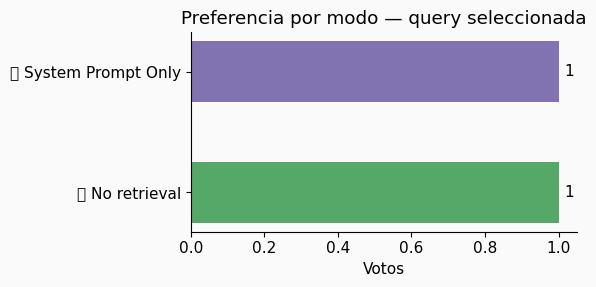

In [12]:
# ── Si la misma query aparece varias veces, mostrar preferencias acumuladas ─
if len(subset) > 1:
    pref_counts = subset['preferred_mode'].value_counts()
    display(Markdown(f"**Preferencias para esta query ({len(subset)} votos):**"))

    fig, ax = plt.subplots(figsize=(6, 3))
    colors = [MODE_COLORS.get(m, '#999') for m in pref_counts.index]
    bars = ax.barh([MODE_LABELS.get(m, m) for m in pref_counts.index],
                   pref_counts.values, color=colors, height=0.5)
    ax.bar_label(bars, padding=4)
    ax.set_xlabel('Votos')
    ax.set_title('Preferencia por modo — query seleccionada')
    plt.tight_layout()
    plt.show()
else:
    print('(Solo una aparición de esta query en el log.)')

## 3. Estadísticas globales de preferencia

In [13]:
counts = df['preferred_mode'].value_counts()
pct    = (counts / counts.sum() * 100).round(1)

summary = pd.DataFrame({'Votos': counts, 'Porcentaje (%)': pct})
summary.index = [MODE_LABELS.get(m, m) for m in summary.index]
display(summary)

winner = counts.idxmax()
print(f"\n🏆 Modo preferido global: {MODE_LABELS.get(winner, winner)} ({pct[winner]}%)")

,Votos,Porcentaje (%)
🧠 No retrieval,2,50.0
📋 System Prompt Only,1,25.0
RAG Hybrid Retrieval,1,25.0



🏆 Modo preferido global: 🧠 No retrieval (50.0%)


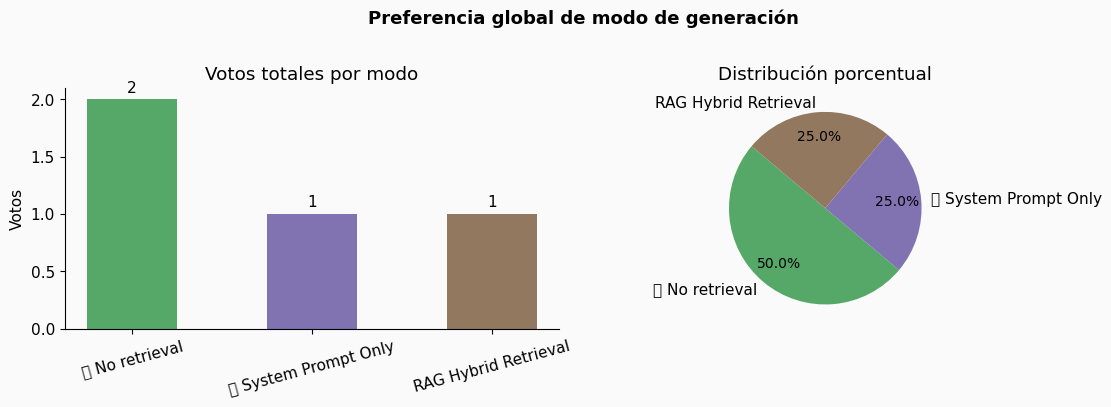

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
ax = axes[0]
colors = [MODE_COLORS.get(m, '#999') for m in counts.index]
bars = ax.bar([MODE_LABELS.get(m, m) for m in counts.index],
              counts.values, color=colors, width=0.5)
ax.bar_label(bars, padding=3)
ax.set_ylabel('Votos')
ax.set_title('Votos totales por modo')
ax.tick_params(axis='x', labelrotation=15)

# Pastel
ax2 = axes[1]
wedge_colors = [MODE_COLORS.get(m, '#999') for m in counts.index]
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=[MODE_LABELS.get(m, m) for m in counts.index],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(10)
ax2.set_title('Distribución porcentual')

plt.suptitle('Preferencia global de modo de generación', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Evolución temporal de preferencias

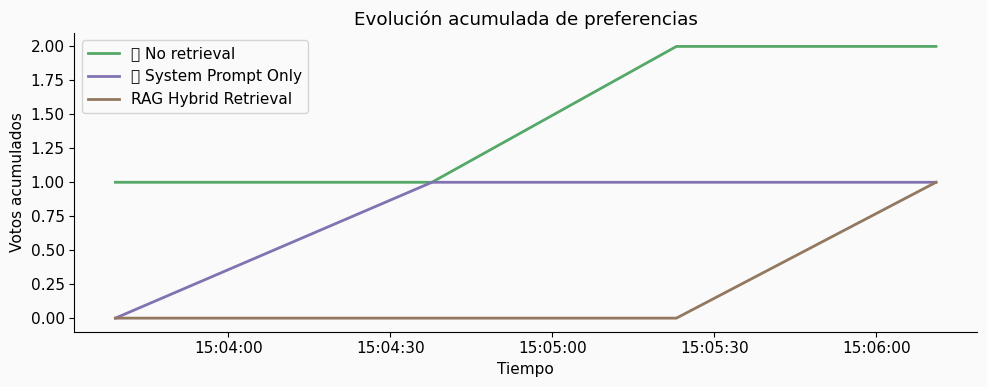

In [17]:
if len(df) < 2:
    print('Insuficientes datos para evolución temporal.')
else:
    df_sorted = df.sort_values('timestamp').copy()

    # Acumulado de votos por modo a lo largo del tiempo
    for mode in MODE_COLORS:
        df_sorted[f'cum_{mode}'] = (df_sorted['preferred_mode'] == mode).cumsum()

    fig, ax = plt.subplots(figsize=(10, 4))
    for mode, color in MODE_COLORS.items():
        ax.plot(df_sorted['timestamp'], df_sorted[f'cum_{mode}'],
                label=MODE_LABELS[mode], color=color, linewidth=2)

    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Votos acumulados')
    ax.set_title('Evolución acumulada de preferencias')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Tabla detallada por query

In [15]:
# Resumen: para cada query única, cuántas veces se evaluó y qué modo ganó
query_summary = (
    df.groupby('query')
    .agg(
        evaluaciones=('preferred_mode', 'count'),
        modo_ganador=('preferred_mode', lambda x: x.value_counts().idxmax()),
        votos_ganador=('preferred_mode', lambda x: x.value_counts().max()),
    )
    .reset_index()
    .sort_values('evaluaciones', ascending=False)
)

query_summary['modo_ganador'] = query_summary['modo_ganador'].map(
    lambda m: MODE_LABELS.get(m, m)
)

# Truncar queries largas para que la tabla sea legible
query_summary['query_corta'] = query_summary['query'].str[:70] + '…'

display(
    query_summary[['query_corta', 'evaluaciones', 'modo_ganador', 'votos_ganador']]
    .rename(columns={
        'query_corta': 'Query',
        'evaluaciones': 'Evaluaciones',
        'modo_ganador': 'Modo preferido',
        'votos_ganador': 'Votos del modo ganador',
    })
    .style.background_gradient(subset=['Evaluaciones'], cmap='Blues')
)

,Query,Evaluaciones,Modo preferido,Votos del modo ganador
1,Cuáles son los efectos secundarios de la quimioterapia?…,2,🧠 No retrieval,1
0,"Acabo de recibir un diagnóstico de cáncer y me siento solo, que hago?…",1,RAG Hybrid Retrieval,1
2,¿Como le explico a mis hijos de 5 años que tengo cáncer?…,1,🧠 No retrieval,1


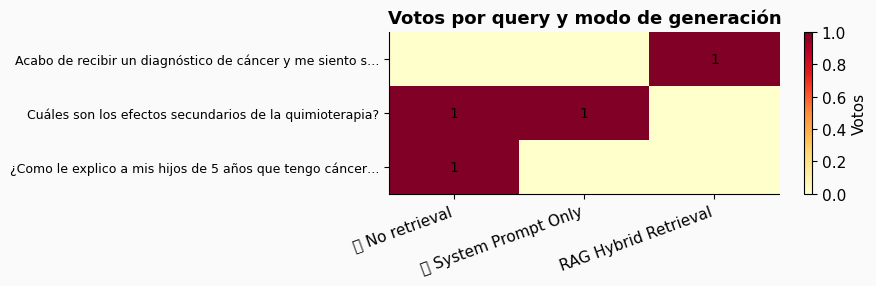

In [16]:
# Mapa de calor: queries (eje Y) × modo (eje X) → nº de votos
pivot = (
    df.groupby(['query', 'preferred_mode'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[m for m in MODE_COLORS if m in df['preferred_mode'].unique()], fill_value=0)
)

# Acortar etiquetas del eje Y
pivot.index = [q[:55] + '…' if len(q) > 55 else q for q in pivot.index]
pivot.columns = [MODE_LABELS.get(c, c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(9, max(3, len(pivot) * 0.55 + 1)))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Votos')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Anotar celdas
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=10, color='black')

ax.set_title('Votos por query y modo de generación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()